In [11]:
import os
import librosa
emodb_path = "../data/emoDB/wav"
print(os.listdir(emodb_path)[:5])

['13a05Nb.wav', '11b10Ad.wav', '14a07Ld.wav', '10b10Fc.wav', '12a01Nb.wav']


In [3]:
# mapping the emotions
def map_emodb_emotion(code):
    mapping = {
        'W': 'angry',
        'L': 'boredom',
        'E': 'disgust',
        'A': 'fear',
        'F': 'happy',
        'T': 'sad',
        'N': 'neutral'
    }
    return mapping.get(code)

In [4]:
def parse_emodb_filename(filename):
    speaker_id = filename[:2]
    emotion_code = filename[5]
    
    emotion = map_emodb_emotion(emotion_code)
    
    return speaker_id, emotion
import pandas as pd

data = []

for file in os.listdir(emodb_path):
    if file.endswith(".wav"):
        speaker, emotion = parse_emodb_filename(file)
        
        data.append({
            "file": file,
            "speaker": speaker,
            "emotion": emotion
        })

df = pd.DataFrame(data)

print(df.head())

          file speaker  emotion
0  13a05Nb.wav      13  neutral
1  11b10Ad.wav      11     fear
2  14a07Ld.wav      14  boredom
3  10b10Fc.wav      10    happy
4  12a01Nb.wav      12  neutral


gender   female  male
emotion              
angry        67    60
boredom      46    35
disgust      35    11
fear         33    36
happy        44    27
neutral      40    39
sad          37    25


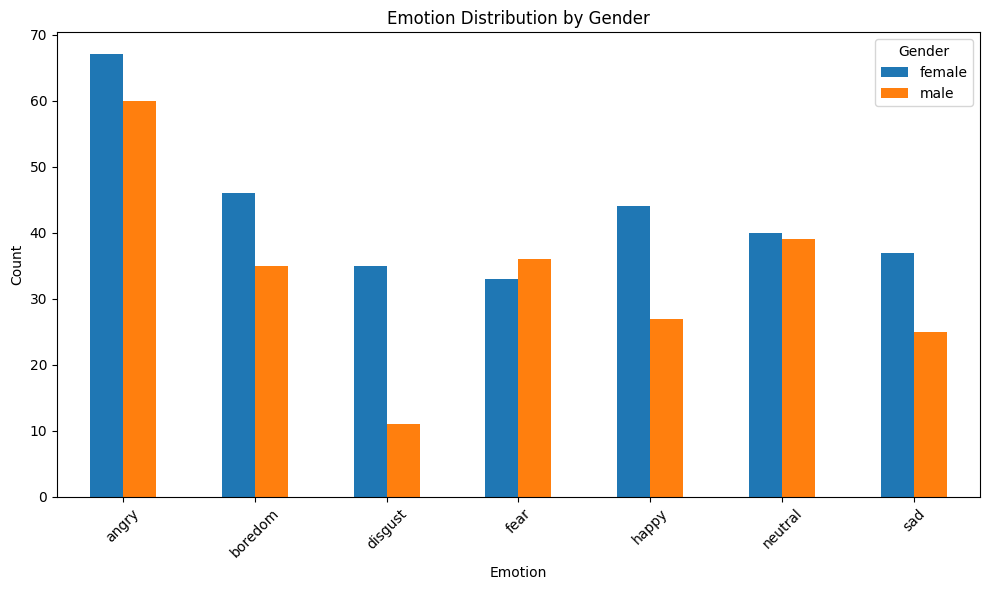

In [6]:
# visualization of emotions and speaker

speaker_gender = {
    '03': 'male',
    '08': 'female',
    '09': 'female',
    '10': 'male',
    '11': 'male',
    '12': 'male',
    '13': 'female',
    '14': 'female',
    '15': 'male',
    '16': 'female'
}
df["gender"] = df["speaker"].map(speaker_gender)

# print(df.head())

gender_emotion_counts = df.groupby(["emotion", "gender"]).size().unstack()

print(gender_emotion_counts)
import matplotlib.pyplot as plt

gender_emotion_counts.plot(kind='bar', figsize=(10, 6))

plt.title("Emotion Distribution by Gender")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="Gender")
plt.tight_layout()

plt.show()

gender
female    302
male      233
Name: count, dtype: int64


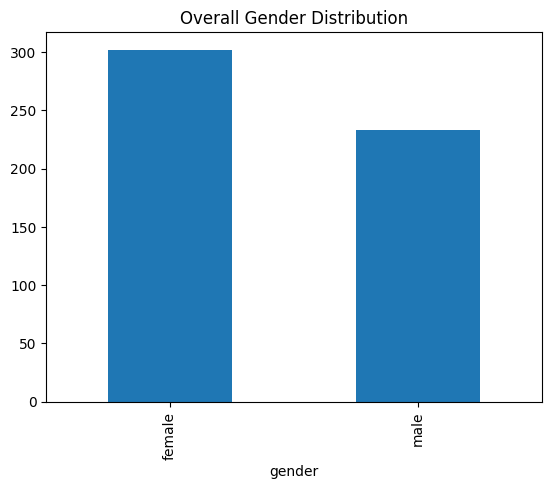

In [8]:
print(df["gender"].value_counts())
df["gender"].value_counts().plot(kind='bar')
plt.title("Overall Gender Distribution")
plt.show()

In [13]:
# augmentation functions
import os
import librosa
import numpy as np
from collections import Counter

def add_noise(signal):
    noise = np.random.normal(0, 0.005, len(signal))
    return signal + noise
    
def time_stretch(signal):
    return librosa.effects.time_stretch(signal, rate=1.1)
    
def pitch_shift(signal, sr):
    return librosa.effects.pitch_shift(signal, sr=sr, n_steps=1)

target_count = 90

X_audio = []
y_audio = []

for emotion in df["emotion"].unique():
    
    emotion_files = df[df["emotion"] == emotion]
    count = len(emotion_files)
    
    print(f"{emotion}: {count} original samples")
    
    # Add original samples
    for _, row in emotion_files.iterrows():
        file_path = os.path.join(emodb_path, row["file"])
        
        signal, sr = librosa.load(file_path, sr=16000)
        
        X_audio.append(signal)
        y_audio.append(emotion)
    
    # Augment if needed
    needed = target_count - count
    
    i = 0
    while needed > 0:
        row = emotion_files.iloc[i % len(emotion_files)]
        
        file_path = os.path.join(emodb_path, row["file"])
        signal, sr = librosa.load(file_path, sr=16000)
        
        # Random augmentation
        aug_type = np.random.choice(["noise", "stretch", "pitch"])
        
        if aug_type == "noise":
            aug_signal = add_noise(signal)
        elif aug_type == "stretch":
            aug_signal = time_stretch(signal)
        else:
            aug_signal = pitch_shift(signal, sr)
        
        X_audio.append(aug_signal)
        y_audio.append(emotion)
        
        needed -= 1
        i += 1
print("Total samples:", len(X_audio))
print("Class distribution:", Counter(y_audio))

neutral: 79 original samples
fear: 69 original samples
boredom: 81 original samples
happy: 71 original samples
sad: 62 original samples
angry: 127 original samples
disgust: 46 original samples
Total samples: 667
Class distribution: Counter({'angry': 127, 'neutral': 90, 'fear': 90, 'boredom': 90, 'happy': 90, 'sad': 90, 'disgust': 90})


In [14]:
# Extracting mfcc

def extract_mfcc(signal, sr=16000, n_mfcc=13, max_len=200):
    
    # Normalize
    if np.max(np.abs(signal)) > 0:
        signal = signal / np.max(np.abs(signal))
    
    mfcc = librosa.feature.mfcc(y=signal, sr=sr, n_mfcc=n_mfcc)
    mfcc = mfcc.T
    
    # Padding / trimming
    if mfcc.shape[0] < max_len:
        mfcc = np.pad(mfcc, ((0, max_len - mfcc.shape[0]), (0, 0)))
    else:
        mfcc = mfcc[:max_len]
    
    return mfcc

X_mfcc = []

for signal in X_audio:
    mfcc = extract_mfcc(signal)
    X_mfcc.append(mfcc)

X_mfcc = np.array(X_mfcc)
y = np.array(y_audio)

print("Shape:", X_mfcc.shape)

Shape: (667, 200, 13)


In [23]:
from collections import Counter
print(Counter(y))
X_flat = X_mfcc.reshape(X_mfcc.shape[0], -1)

print("Flattened shape:", X_flat.shape)

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_encoded = le.fit_transform(y)

print(le.classes_)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_flat)

Counter({'angry': 127, 'neutral': 90, 'fear': 90, 'boredom': 90, 'happy': 90, 'sad': 90, 'disgust': 90})
Flattened shape: (667, 2600)
['angry' 'boredom' 'disgust' 'fear' 'happy' 'neutral' 'sad']


In [22]:
import numpy as np

# indices of all samples
indices = np.arange(len(y))
angry_indices = indices[y == 'angry']
other_indices = indices[y != 'angry']
np.random.seed(42)  # reproducibility

selected_angry = np.random.choice(angry_indices, size=90, replace=False)
final_indices = np.concatenate([selected_angry, other_indices])
X_mfcc_balanced = X_mfcc[final_indices]
y_balanced = y[final_indices]
from sklearn.utils import shuffle

X_mfcc_balanced, y_balanced = shuffle(X_mfcc_balanced, y_balanced, random_state=42)
from collections import Counter

print(Counter(y_balanced))
print("New shape:", X_mfcc_balanced.shape)

Counter({'sad': 90, 'fear': 90, 'disgust': 90, 'angry': 90, 'neutral': 90, 'happy': 90, 'boredom': 90})
New shape: (630, 200, 13)


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, random_state=42
)
from sklearn.svm import SVC

svm = SVC(kernel='rbf', C=10, gamma='scale', class_weight='balanced')
svm.fit(X_train, y_train)
from sklearn.metrics import classification_report

y_pred = svm.predict(X_test)

print("Accuracy:", svm.score(X_test, y_test))
print(classification_report(y_test, y_pred))

Accuracy: 0.7686567164179104
              precision    recall  f1-score   support

           0       0.78      0.91      0.84        23
           1       0.61      0.61      0.61        18
           2       0.94      0.83      0.88        18
           3       0.89      0.89      0.89        18
           4       0.58      0.41      0.48        17
           5       0.86      0.73      0.79        26
           6       0.67      1.00      0.80        14

    accuracy                           0.77       134
   macro avg       0.76      0.77      0.76       134
weighted avg       0.77      0.77      0.76       134

